In [0]:
from pyspark.sql.functions import col
appointments_data = [
(1001, "Hyderabad", "Cardiology", "Apollo", 1500, "Completed"),
(1002, "Bangalore", "Neurology", "Yashoda", 2200, "Completed"),
(1003, "Mumbai", "Dermatology", "Care", 900, "Pending"),
(1004, "Delhi", "Orthopedics", "Max", 2500, "Completed"),
(1005, "Chennai", "Pediatrics", "Apollo", 1200, "Cancelled"),
(1006, "Hyderabad", "Cardiology", "Care", 3000, "Completed"),
(1007, "Bangalore", "Dermatology", "Apollo", 1000, "Completed"),
(1008, "Mumbai", "Neurology", "Max", 2600, "Pending"),
(1009, "Delhi", "Cardiology", "Yashoda", 2800, "Completed"),
(1010, "Chennai", "Orthopedics", "Care", 2400, "Completed"),
(1011, "Hyderabad", "Pediatrics", "Apollo", 1100, "Completed"),
(1012, "Bangalore", "Cardiology", "Max", 3200, "Completed"),
(1013, "Mumbai", "Pediatrics", "Yashoda", 1300, "Cancelled"),
(1014, "Delhi", "Neurology", "Apollo", 2700, "Completed"),
(1015, "Chennai", "Dermatology", "Care", 950, "Pending")
]
columns = [
"appointment_id",
"city",
"department",
"hospital",
"consultation_fee",
"status"
]
df = spark.createDataFrame(appointments_data, columns)
display(df)

appointment_id,city,department,hospital,consultation_fee,status
1001,Hyderabad,Cardiology,Apollo,1500,Completed
1002,Bangalore,Neurology,Yashoda,2200,Completed
1003,Mumbai,Dermatology,Care,900,Pending
1004,Delhi,Orthopedics,Max,2500,Completed
1005,Chennai,Pediatrics,Apollo,1200,Cancelled
1006,Hyderabad,Cardiology,Care,3000,Completed
1007,Bangalore,Dermatology,Apollo,1000,Completed
1008,Mumbai,Neurology,Max,2600,Pending
1009,Delhi,Cardiology,Yashoda,2800,Completed
1010,Chennai,Orthopedics,Care,2400,Completed


In [0]:
from pyspark.sql.functions import *

In [0]:
import matplotlib.pyplot as plt
pdf = df.toPandas()

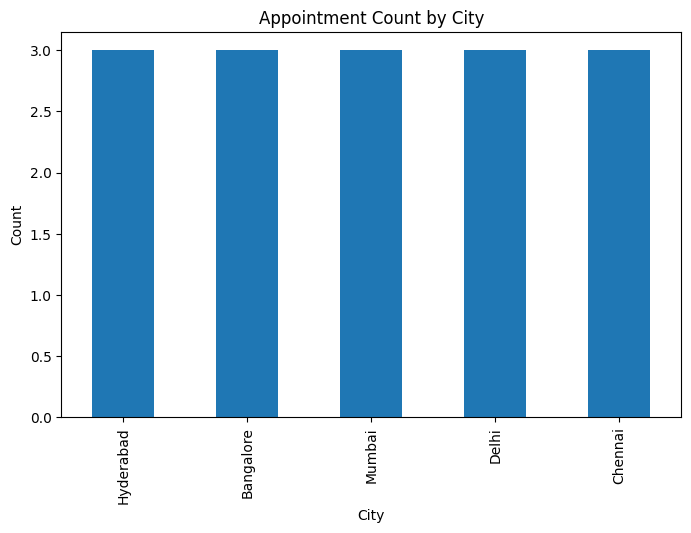

In [0]:
city_count = pdf['city'].value_counts()

plt.figure(figsize=(8,5))
city_count.plot(kind='bar')
plt.title('Appointment Count by City')
plt.xlabel('City')
plt.ylabel('Count')
plt.show()

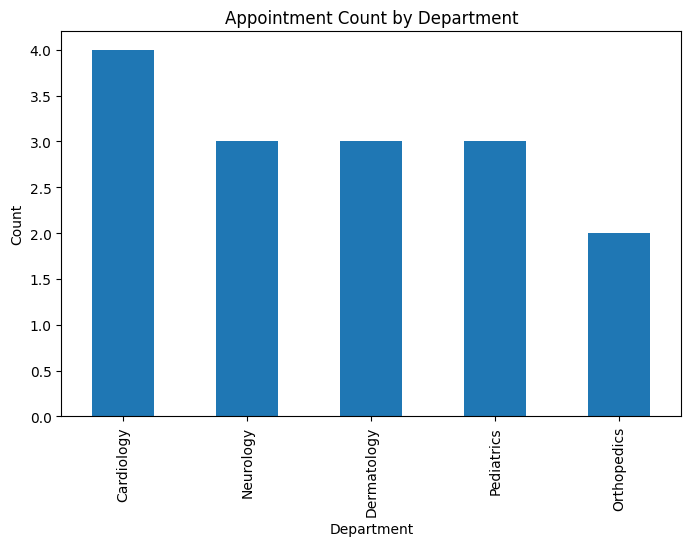

In [0]:
dept_count = pdf['department'].value_counts()

plt.figure(figsize=(8,5))
dept_count.plot(kind='bar')
plt.title('Appointment Count by Department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.show()

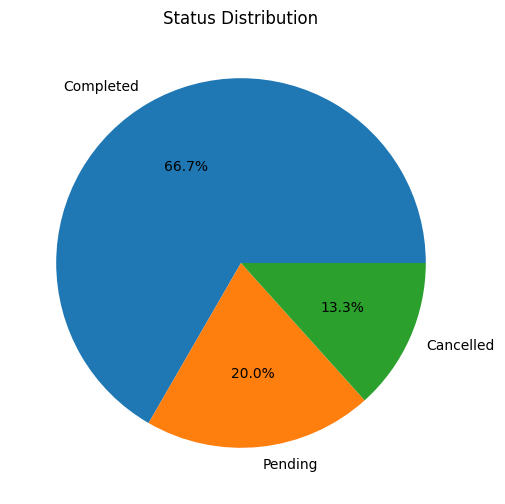

In [0]:
status_count=pdf['status'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(status_count, labels=status_count.index, autopct='%1.1f%%')
plt.title('Status Distribution')
plt.show()

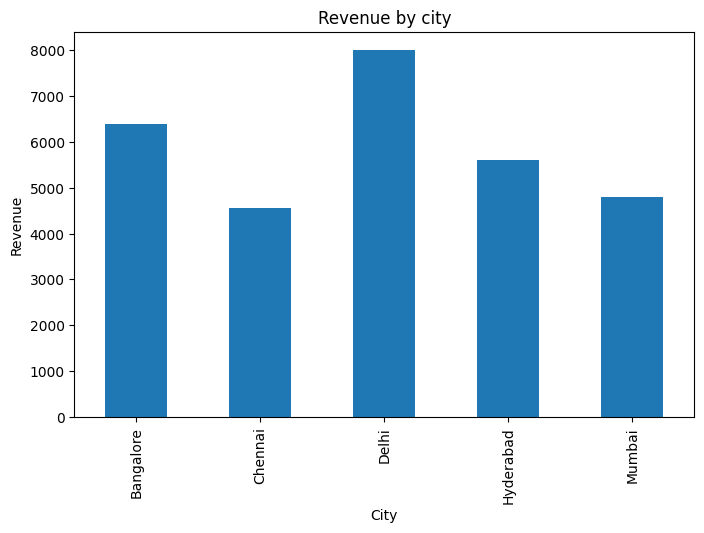

In [0]:
city_rev=pdf.groupby('city')['consultation_fee'].sum()
plt.figure(figsize=(8,5))
city_rev.plot(kind='bar')
plt.title('Revenue by city')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.show()

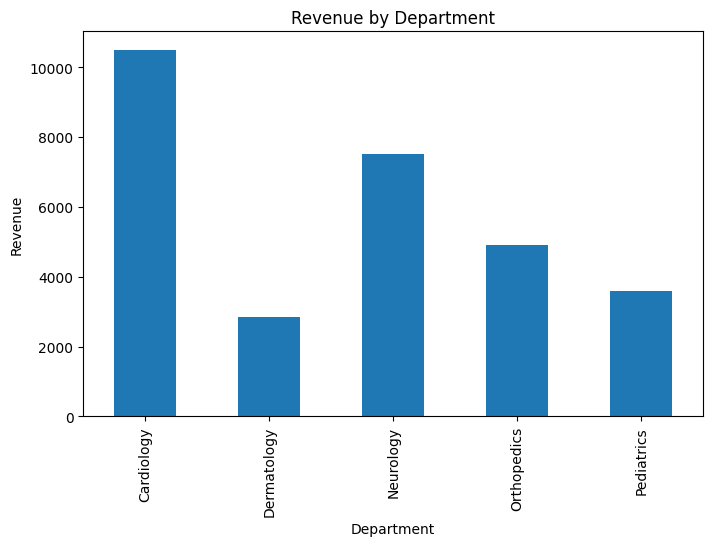

In [0]:
dep_rev=pdf.groupby('department')['consultation_fee'].sum()
plt.figure(figsize=(8,5))
dep_rev.plot(kind='bar')
plt.title('Revenue by Department')
plt.xlabel('Department')
plt.ylabel('Revenue')
plt.show()

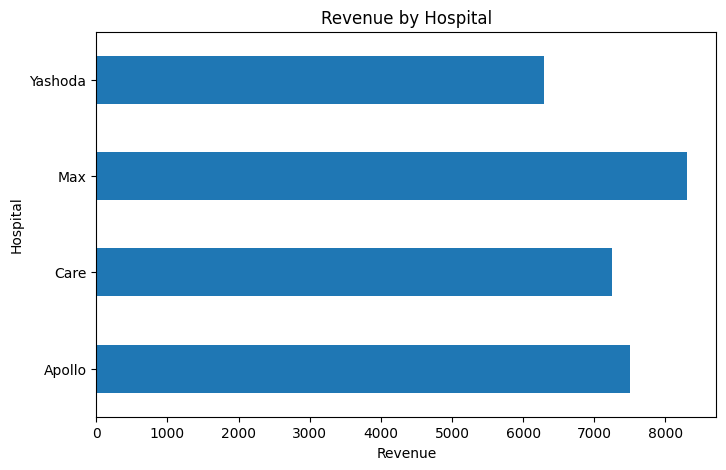

In [0]:
hos_rev=pdf.groupby('hospital')['consultation_fee'].sum()
plt.figure(figsize=(8,5))
hos_rev.plot(kind='barh')
plt.title('Revenue by Hospital')
plt.xlabel('Revenue')
plt.ylabel('Hospital')
plt.show()

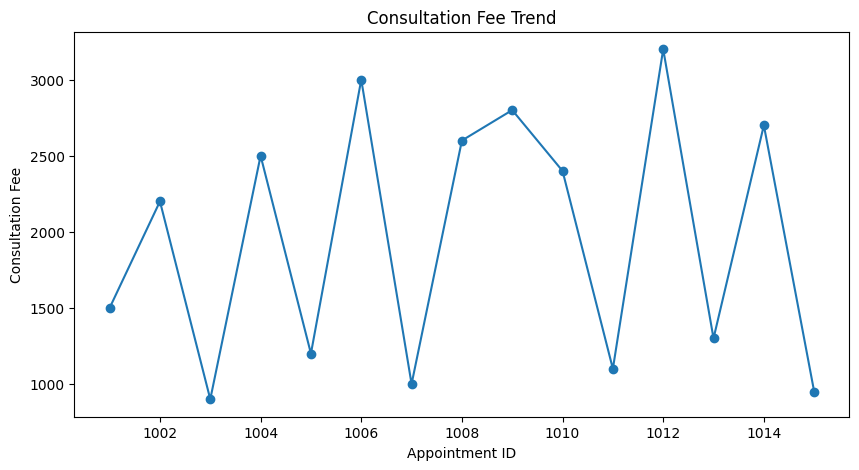

In [0]:
plt.figure(figsize=(10,5))
plt.plot(pdf['appointment_id'], pdf['consultation_fee'], marker='o')
plt.title('Consultation Fee Trend')
plt.xlabel('Appointment ID')
plt.ylabel('Consultation Fee')
plt.show()

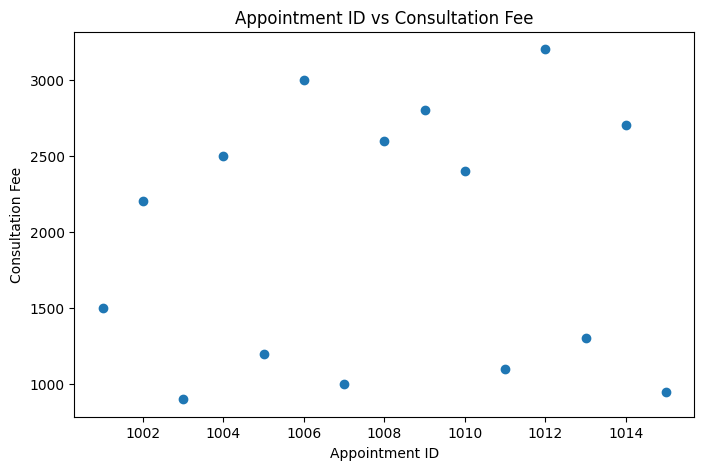

In [0]:
plt.figure(figsize=(8,5))
plt.scatter(pdf['appointment_id'],pdf['consultation_fee'])
plt.title('Appointment ID vs Consultation Fee')
plt.xlabel('Appointment ID')
plt.ylabel('Consultation Fee')
plt.show()

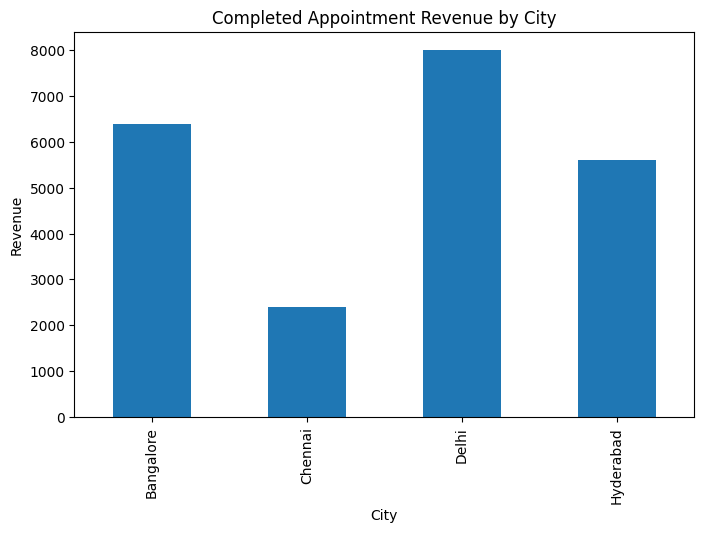

In [0]:
completed=pdf[pdf['status']=='Completed']
com_rev=completed.groupby('city')['consultation_fee'].sum()
plt.figure(figsize=(8,5))
com_rev.plot(kind='bar')
plt.title('Completed Appointment Revenue by City')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.show()

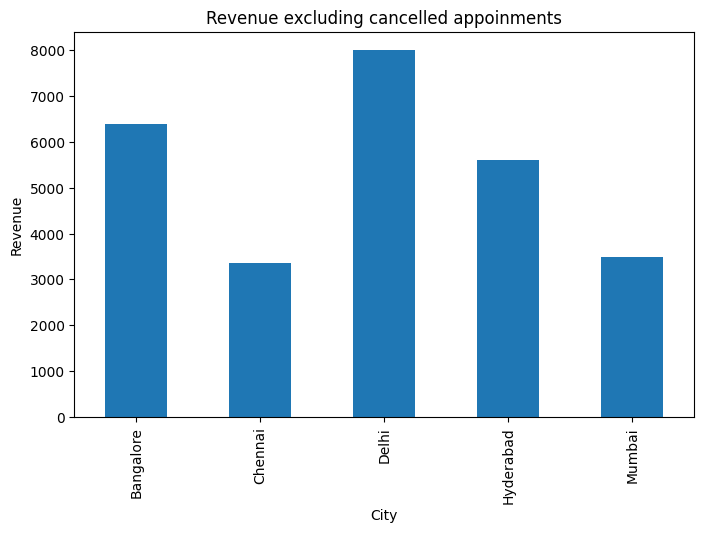

In [0]:
valid=pdf[pdf['status']!='Cancelled']
valid_rev=valid.groupby('city')['consultation_fee'].sum()
plt.figure(figsize=(8,5))
valid_rev.plot(kind='bar')
plt.title('Revenue excluding cancelled appoinments')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.show()

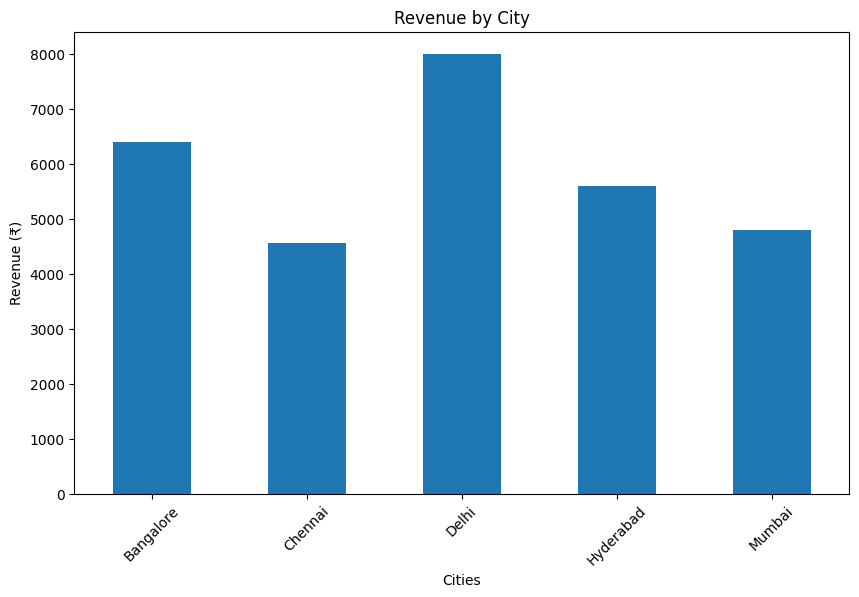

In [0]:
city_revenue = pdf.groupby('city')['consultation_fee'].sum()

plt.figure(figsize=(10,6))          

city_revenue.plot(kind='bar')

plt.title('Revenue by City')         
plt.xlabel('Cities')                 
plt.ylabel('Revenue (₹)')            

plt.xticks(rotation=45)              
plt.show()

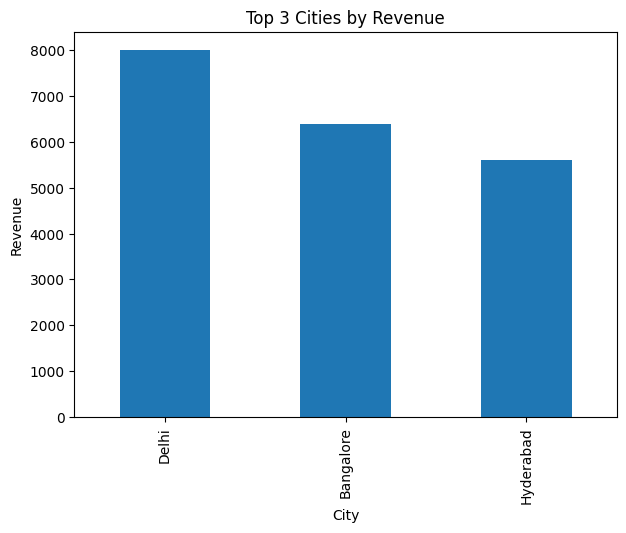

In [0]:
top3_city = pdf.groupby('city')['consultation_fee'].sum().sort_values(ascending=False).head(3)

plt.figure(figsize=(7,5))
top3_city.plot(kind='bar')
plt.title('Top 3 Cities by Revenue')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.show()

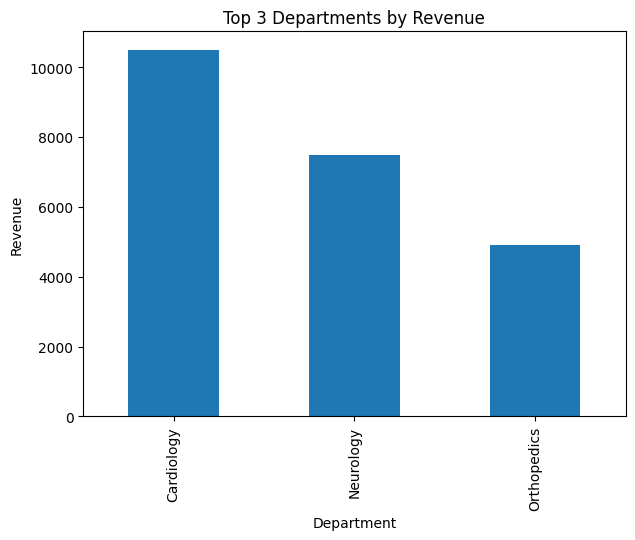

In [0]:
top3_dept = pdf.groupby('department')['consultation_fee'].sum().sort_values(ascending=False).head(3)

plt.figure(figsize=(7,5))
top3_dept.plot(kind='bar')
plt.title('Top 3 Departments by Revenue')
plt.xlabel('Department')
plt.ylabel('Revenue')
plt.show()

In [0]:
lowest_rev_hospital = hos_rev.sort_values().head(1)
print(lowest_rev_hospital)

hospital
Yashoda    6300
Name: consultation_fee, dtype: int64


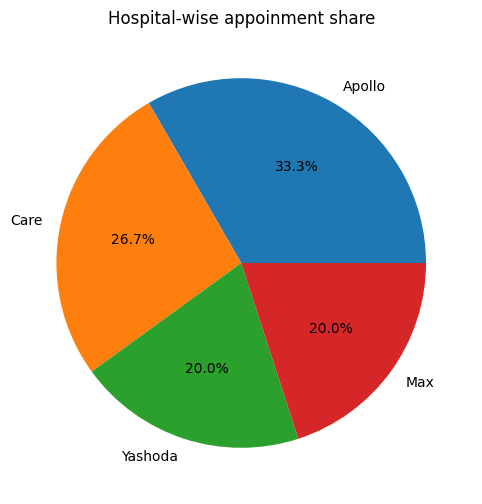

In [0]:
hospital_count=pdf['hospital'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(hospital_count, labels=hospital_count.index, autopct='%1.1f%%')
plt.title('Hospital-wise appoinment share')
plt.show()

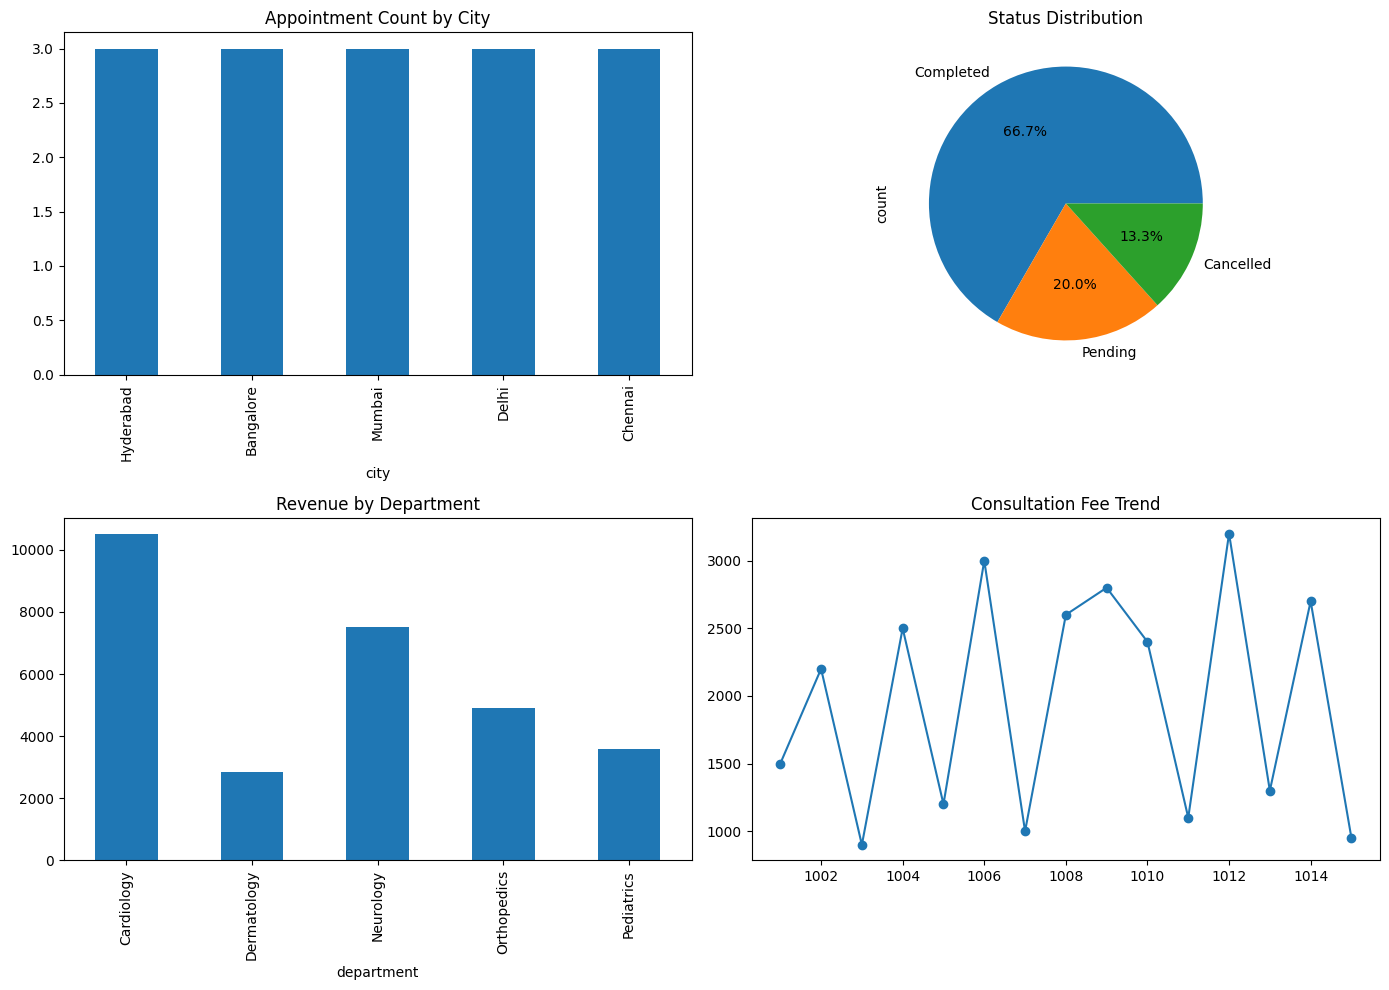

In [0]:
fig, ax = plt.subplots(2,2, figsize=(14,10))

pdf['city'].value_counts().plot(kind='bar', ax=ax[0,0], title='Appointment Count by City')

pdf['status'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[0,1], title='Status Distribution')

pdf.groupby('department')['consultation_fee'].sum().plot(kind='bar', ax=ax[1,0], title='Revenue by Department')

ax[1,1].plot(pdf['appointment_id'], pdf['consultation_fee'], marker='o')
ax[1,1].set_title('Consultation Fee Trend')

plt.tight_layout()
plt.show()